In [4]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
import seaborn as sns
import os
os.getcwd()

'C:\\Users\\ngarg\\Downloads'

In [5]:
df = pd.read_csv("C:\\Users\\ngarg\\Downloads/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.shape

(1338, 7)

In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


EDA

In [10]:
num_cols = df.select_dtypes(include='number').columns

In [11]:
num_cols

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

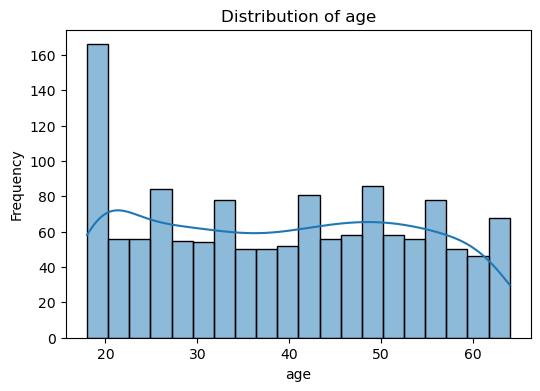

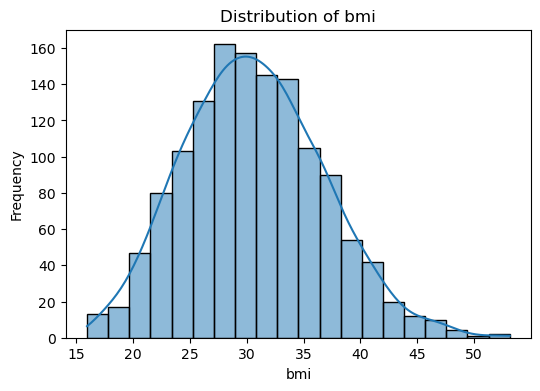

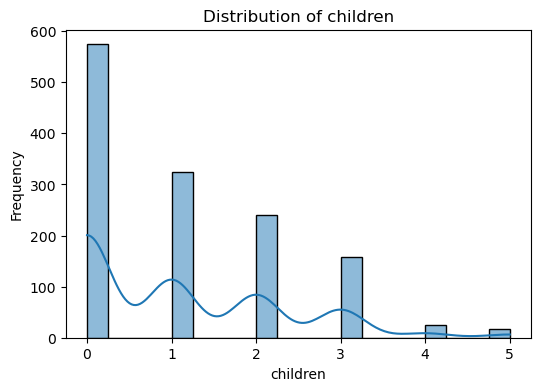

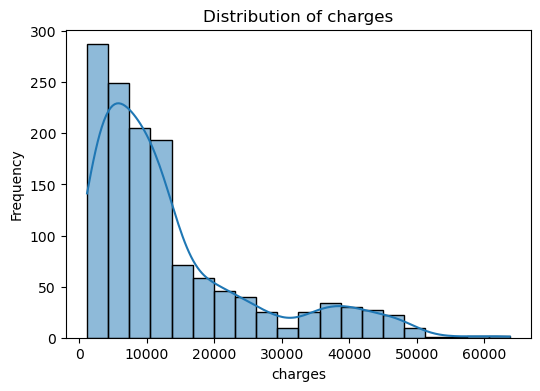

In [12]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    

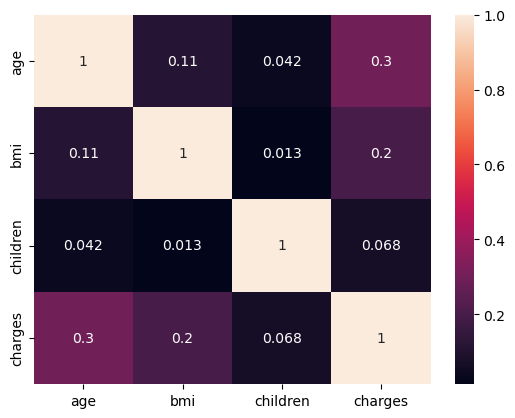

In [13]:
sns.heatmap(df.corr(numeric_only = True) ,annot = True)
plt.show()

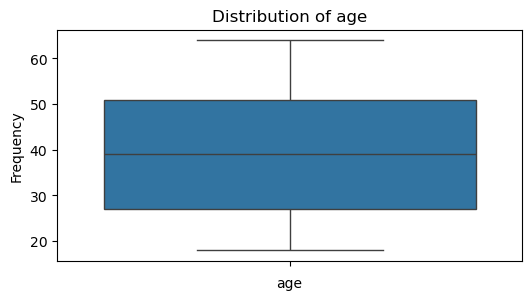

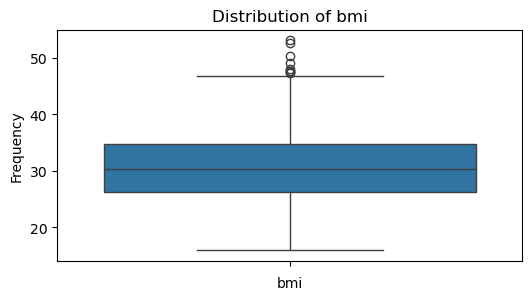

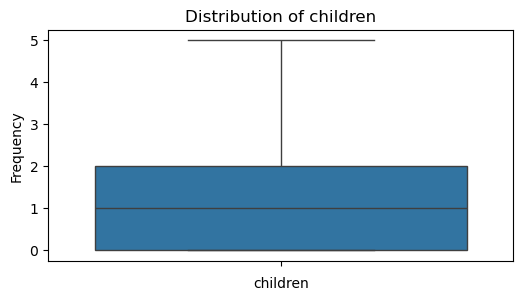

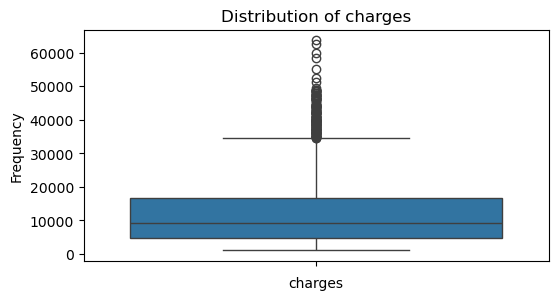

In [14]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(df[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [15]:
df_cleaned = df.copy()
df_cleaned.shape

(1338, 7)

In [16]:
df_cleaned.drop_duplicates().shape

(1337, 7)

In [17]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [18]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [19]:
df_cleaned['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [20]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male" : 0 , "female" : 1})

In [21]:
df_cleaned["sex"].value_counts()

sex
0    676
1    662
Name: count, dtype: int64

In [22]:
df_cleaned['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [23]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({"no" : 0 , "yes" : 1})

In [24]:
df_cleaned['smoker'].value_counts()

smoker
0    1064
1     274
Name: count, dtype: int64

In [25]:
df_cleaned.rename(columns = {
    'sex' : 'is_female' , 
    'smoker' : 'is_smoker'
} , inplace = True)

In [26]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [27]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [28]:
df_cleaned = pd.get_dummies(df_cleaned , columns = ['region']  , drop_first = True)

In [29]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False
1334,18,1,31.920,0,0,2205.98080,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,True


In [30]:
df_cleaned.astype(int)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


Feature Engeenerieng

<Axes: xlabel='bmi', ylabel='Count'>

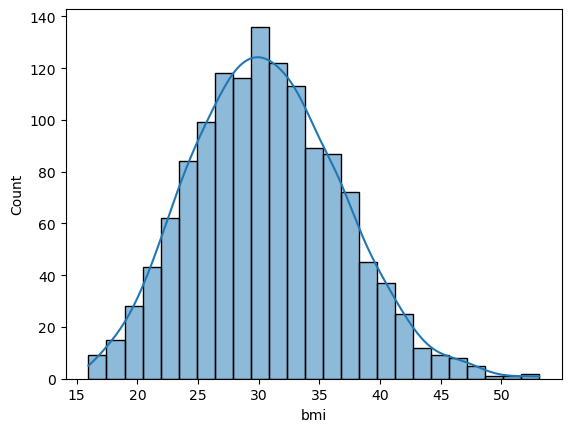

In [31]:
sns.histplot(df['bmi'] , kde = True)

In [32]:
df_cleaned['bmi category'] = pd.cut(
    df_cleaned['bmi'],
    bins = [0 , 18.5 , 24.9 , 29.9 , float('inf')],
    labels = ["Underweight","Normal","Overweight","Obese"]
)

In [33]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi category
0,19,1,27.900,0,1,16884.92400,False,False,True,Overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,Obese
2,28,0,33.000,3,0,4449.46200,False,True,False,Obese
3,33,0,22.705,0,0,21984.47061,True,False,False,Normal
4,32,0,28.880,0,0,3866.85520,True,False,False,Overweight


In [34]:
df_cleaned = pd.get_dummies(df_cleaned , columns = ['bmi category'] , drop_first  = True)

In [35]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_Normal,bmi category_Overweight,bmi category_Obese
0,19,1,27.900,0,1,16884.92400,False,False,True,False,True,False
1,18,0,33.770,1,0,1725.55230,False,True,False,False,False,True
2,28,0,33.000,3,0,4449.46200,False,True,False,False,False,True
3,33,0,22.705,0,0,21984.47061,True,False,False,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,False,False,True
1334,18,1,31.920,0,0,2205.98080,False,False,False,False,False,True
1335,18,1,36.850,0,0,1629.83350,False,True,False,False,False,True
1336,21,1,25.800,0,0,2007.94500,False,False,True,False,True,False


In [36]:
df_cleaned = df_cleaned.astype(int)

In [37]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_Normal,bmi category_Overweight,bmi category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [38]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi category_Normal', 'bmi category_Overweight', 'bmi category_Obese'],
      dtype='object')

In [39]:
from sklearn.preprocessing import StandardScaler
cols = ['age' , 'bmi' , 'children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [40]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi category_Normal,bmi category_Overweight,bmi category_Obese
0,-1.438764,1,-0.518122,-0.908614,1,16884,0,0,1,0,1,0
1,-1.509965,0,0.462657,-0.078767,0,1725,0,1,0,0,0,1
2,-0.797954,0,0.462657,1.580926,0,4449,0,1,0,0,0,1
3,-0.441948,0,-1.335438,-0.908614,0,21984,1,0,0,1,0,0
4,-0.513149,0,-0.354659,-0.908614,0,3866,1,0,0,0,1,0


In [41]:
from scipy.stats import pearsonr
selected_features = df_cleaned.columns.drop("charges")
correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned["charges"])[0]
    for feature in selected_features
}
correlations_df = pd.DataFrame(list(correlations.items()) , columns = ['feature' , 'Pearson Correlation'])
correlations_df.sort_values(by = 'Pearson Correlation' , ascending = False)

,feature,Pearson Correlation
4,is_smoker,0.787251
0,age,0.299009
10,bmi category_Obese,0.196858
2,bmi,0.196188
6,region_southeast,0.073981
3,children,0.067999
5,region_northwest,-0.039905
7,region_southwest,-0.043210
1,is_female,-0.057293
8,bmi category_Normal,-0.105292


In [42]:
selected_features = df_cleaned.columns.drop(["charges" , "age" , "children" , "bmi"])

In [43]:
from scipy.stats import chi2_contingency

alpha = 0.05

df_cleaned["charges_bin"] = pd.qcut(
    df_cleaned["charges"],
    q=4,
    labels=False
)

chi2_results = {}

for col in selected_features:
    contingency = pd.crosstab(
        df_cleaned[col],
        df_cleaned["charges_bin"]
    )

    chi2_stat, p_val, _, _ = chi2_contingency(contingency)

    decision = (
        "Reject Null (Keep Feature)"
        if p_val < alpha
        else "Fail to Reject Null (Reject Feature)"
    )

    chi2_results[col] = {
        "chi2_statistic": chi2_stat,
        "p_value": p_val,
        "Decision": decision
    }

In [44]:
chi2_results_df = (
    pd.DataFrame(chi2_results).T
)

chi2_results_df.sort_values("p_value")

,chi2_statistic,p_value,Decision
is_smoker,854.020268,0.0,Reject Null (Keep Feature)
region_southeast,15.208814,0.001647,Reject Null (Keep Feature)
is_female,9.532132,0.022992,Reject Null (Keep Feature)
bmi category_Obese,7.619834,0.054558,Fail to Reject Null (Reject Feature)
region_southwest,5.530825,0.136807,Fail to Reject Null (Reject Feature)
bmi category_Overweight,4.627677,0.201181,Fail to Reject Null (Reject Feature)
bmi category_Normal,4.134905,0.24726,Fail to Reject Null (Reject Feature)
region_northwest,1.226112,0.746749,Fail to Reject Null (Reject Feature)


In [45]:
df_selected = df_cleaned.drop(columns=[
    "bmi category_Obese",
    "region_southwest",
    "bmi category_Overweight",
    "bmi category_Normal",
    "region_northwest",
    "charges_bin"
])

df_selected.head()

,age,is_female,bmi,children,is_smoker,charges,region_southeast
0,-1.438764,1,-0.518122,-0.908614,1,16884,0
1,-1.509965,0,0.462657,-0.078767,0,1725,1
2,-0.797954,0,0.462657,1.580926,0,4449,1
3,-0.441948,0,-1.335438,-0.908614,0,21984,0
4,-0.513149,0,-0.354659,-0.908614,0,3866,0


Linear Regression Model 


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

x = df_selected.drop(columns = ['charges'])
y = df_selected['charges']

train_x , test_x , train_y , test_y = train_test_split(x , y, test_size = 0.2 , random_state = 42)
linear = LinearRegression()

n = test_x.shape[0]
p = test_x.shape[1]

linear.fit(train_x , train_y)
predict_y = linear.predict(test_x)

r2 = r2_score(test_y , predict_y)
r2


0.7823401263526357

In [53]:
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
adjusted_r2

0.7773364510963745